In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import mlflow
import mlflow.sklearn

In [22]:
df = pd.read_csv("../../data/crime_500k_cleaned.csv")

In [23]:
cat_columns = df.select_dtypes(include="object").columns
num_columns = df.select_dtypes(include=["int64","float64"]).columns
print(cat_columns)
print(num_columns)

Index(['Primary Type', 'Season'], dtype='object')
Index(['Arrest', 'Domestic', 'District', 'Community Area', 'Year', 'Latitude',
       'Longitude', 'Hour', 'Day', 'Day_of_Week', 'Month', 'Is_Weekend',
       'Crime_Severity_Score'],
      dtype='object')


In [24]:
label_encoder = LabelEncoder()
df["Primary Type"] = label_encoder.fit_transform(df["Primary Type"])
df["Season"] = label_encoder.fit_transform(df["Season"])

In [25]:
X = df[["Latitude","Longitude"]].sample(100000, random_state=42)

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
pickle.dump(scaler, open("../../models/dbscan_scaler.pkl", "wb"))

In [28]:
eps = 0.2
dbscan = DBSCAN(eps=eps, min_samples=15)
db_labels = dbscan.fit_predict(X_scaled)

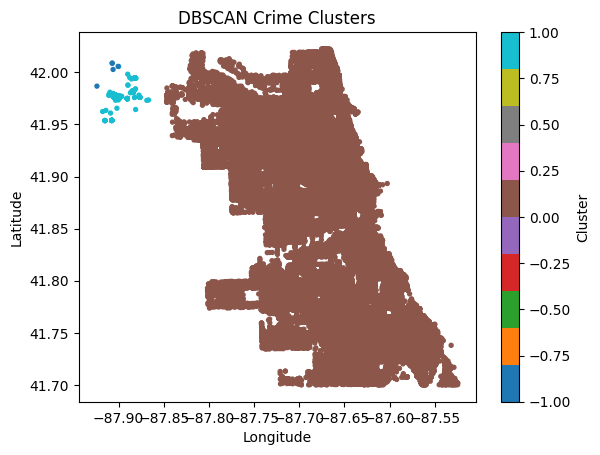

In [29]:
plt.scatter(
    X["Longitude"],
    X["Latitude"],
    c=db_labels,
    cmap="tab10",
    s=8
)

plt.title("DBSCAN Crime Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(label="Cluster")
plt.show()

In [30]:
Silhouette_score = silhouette_score(X_scaled, db_labels)
print("Silhouette Score:", Silhouette_score)

Silhouette Score: 0.5567491841559539


In [31]:
davies_bouldin_score = davies_bouldin_score(X_scaled, db_labels)
print(davies_bouldin_score)

0.5954674367232308


In [32]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Clustering")
with mlflow.start_run(run_name="DBSCAN"):
    mlflow.log_param("eps", eps)
    mlflow.log_param("min_samples", 15)
    mlflow.log_metric("silhouette_score", Silhouette_score)
    mlflow.log_metric("davies_bouldin_score", davies_bouldin_score)
    mlflow.sklearn.log_model(dbscan, "DBSCAN_model")

2026/03/11 15:22:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 15:22:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/11 15:22:31 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


🏃 View run DBSCAN at: http://127.0.0.1:5000/#/experiments/2/runs/3447554648a246e4a64f719ce00a2ee5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [33]:
with open("../../models/dbscan.pkl", "wb") as f:
    pickle.dump(dbscan, f)